# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [73]:
# Import warnings
import warnings


In [4]:
# Import the libraries you will be using for analysis

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.1.3
pandas version: 2.2.3
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [76]:
# Try loading one file
df = pd.read_parquet("2023-1.parquet")
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

(3041714, 19)

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [112]:
# from google.colab import drive
# drive.mount('/content/drive')


In [82]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
#os.chdir('Graded Assignment Dataset')

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
#insted of dataframe i have used below initilization because it is fast and efficient and provide clear error handling. Dataframe causes internal loops and 
#if fail in between , partially merged data still wil be there. 
sampled_monthData = []

# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        df = pd.read_parquet(file_path)

        df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])

        df["tpep_pickup_date"] = df["tpep_pickup_datetime"].dt.date
        df["tpep_pickup_hour"] = df["tpep_pickup_datetime"].dt.hour

        hourly_sampled = []    # hourly sampled data
        #Sample 5 % per hour per day
         # Loop through dates and then loop through every hour of each date

        for date in df["tpep_pickup_date"].unique():
            df_date = df[df["tpep_pickup_date"] == date]
            
             # Iterate through each hour of the selected date
            for hour in df_date["tpep_pickup_hour"].unique():
                df_hour = df_date[df_date["tpep_pickup_hour"] == hour]
                
                # Sample 5% of the hourly data randomly
                df_sampled_hour = df_hour.sample(frac=0.05, random_state=42)
                
                # add data of this hour to the dataframe
                hourly_sampled.append(df_sampled_hour)
         # Concatenate all hourly sampled data for this file       
        file_sampled_df = pd.concat(hourly_sampled, ignore_index=True)  
        
        sampled_monthData.append(file_sampled_df)  #monthly data
       
    except Exception as e:
      print(f"Error reading file {file_name}: {e}")

# Concatenate the sampled data of all the dates to a single dataframe
if sampled_monthData:
    sampled_yearData = pd.concat(sampled_monthData, ignore_index=True)   #year data


sampled_yearData.shape


(1896400, 22)

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [86]:
# Store the df in csv/parquet
sampled_yearData.shape
sampled_yearData.to_parquet("SampleData.parquet")

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [489]:
# Load the new data file
file_path = os.path.join(os.getcwd(), "SampleData.parquet")
df = pd.read_parquet(file_path)
df.shape

(1896400, 22)

In [490]:
df.head()
df.describe()
df.shape

(1896400, 22)

In [491]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee           

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [492]:
# Fix the index and drop any columns that are not needed
df.reset_index(drop=True,inplace=True)
#store_and_fwd_flag may not be of any use in analysis of this data
df.drop("store_and_fwd_flag",axis=1,inplace=True)
print(df.columns)
df.shape

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID',
       'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
       'congestion_surcharge', 'airport_fee', 'tpep_pickup_date',
       'tpep_pickup_hour', 'Airport_fee'],
      dtype='object')


(1896400, 21)

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [493]:
# Combine the two airport fee columns
print(df["Airport_fee"].isna().sum())
print(df["airport_fee"].isna().sum())

# Where both value exists 
both_present = df[
    ~df["airport_fee"].isna() & ~df["Airport_fee"].isna()
]
print(both_present.shape)

#Since Airport_fee has less null column and we identified that there is no single record where both value exists. Hance we will fill null records of Airport_fee columns with records of ~airport_fee
df["Airport_fee"] = df["Airport_fee"].fillna(df["airport_fee"])

#drop airport_fee column as its have mostly null values
df.drop("airport_fee",axis=1,inplace=True)
df.shape

213357
1747917
(0, 21)


(1896400, 20)

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [494]:
# check where values of fare amount are negative
df[df["fare_amount"] < 0]


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,tpep_pickup_date,tpep_pickup_hour,Airport_fee


Did you notice something different in the `RatecodeID` column for above records?

In [495]:
# Analyse RatecodeID for the negative fare amounts
df[df["fare_amount"] < 0]  # There is no record with negative Fare amount 


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,tpep_pickup_date,tpep_pickup_hour,Airport_fee


In [498]:
# Find which columns have negative values
#First we need to fetch all numeric columns 
numeric_cols = df.select_dtypes(include="number").columns

cols_with_negative_values = [
    col for col in numeric_cols if (df[col] < 0).any()
]

cols_with_negative_values


[]

In [497]:
# fix these negative values

df.loc[df["extra"]< 0,"extra"] = 0
df.loc[df["mta_tax"]< 0,"mta_tax"] = 0
df.loc[df["improvement_surcharge"]< 0,"improvement_surcharge"] = 0
df.loc[df["congestion_surcharge"]< 0,"congestion_surcharge"] = 0
df.loc[df["Airport_fee"]< 0,"Airport_fee"] = 0


df["recalculate_total_amount"] = (
    df["fare_amount"]
    + df["extra"]
    + df["mta_tax"]
    + df["improvement_surcharge"]
    + df["congestion_surcharge"]
    + df["Airport_fee"]
    + df["tip_amount"]
    + df["tolls_amount"]
)

df["total_amount"] = df["recalculate_total_amount"]
df.drop(columns="recalculate_total_amount",axis=1, inplace=True)
df.shape

(1896400, 20)

### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [499]:
# Find the proportion of missing values in each column
(df.isna().sum()/df.shape[0])*100

VendorID                 0.000000
tpep_pickup_datetime     0.000000
tpep_dropoff_datetime    0.000000
passenger_count          3.420903
trip_distance            0.000000
RatecodeID               3.420903
PULocationID             0.000000
DOLocationID             0.000000
payment_type             0.000000
fare_amount              0.000000
extra                    0.000000
mta_tax                  0.000000
tip_amount               0.000000
tolls_amount             0.000000
improvement_surcharge    0.000000
total_amount             3.420903
congestion_surcharge     3.420903
tpep_pickup_date         0.000000
tpep_pickup_hour         0.000000
Airport_fee              3.420903
dtype: float64

**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [500]:
# Display the rows with null values
df[df.isna().any(axis=1)]

# Impute NaN values in 'passenger_count'
df["passenger_count"].value_counts().sort_index()

# There are 29681 recrods with 0 passanger_count that need to be handled as it seems genuine trip data
# Replaced 0 and nan values with median number of passangers
df.loc[df["passenger_count"]==0,"passenger_count"] = np.nan

median_passangers_count = df["passenger_count"].median()

df["passenger_count"] = (
    df["passenger_count"]
    .fillna(median_passangers_count)
    .astype(int)
)

df["passenger_count"].value_counts().sort_index()

passenger_count
1    1471779
2     277298
3      69034
4      38537
5      23871
6      15860
7          5
8         11
9          5
Name: count, dtype: int64

Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [501]:
# Fix missing values in 'RatecodeID'
df["RatecodeID"] = (df["RatecodeID"].fillna(99).astype(float))

**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [502]:
# handle null values in congestion_surcharge
df["congestion_surcharge"].isna().sum()
df["congestion_surcharge"] = (df["congestion_surcharge"].fillna(0).astype(float))
df["congestion_surcharge"].isna().sum()

np.int64(0)

Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [503]:
# Handle any remaining missing values
df.isna().sum()
# In airport fee column all the null values are for RatecodeID null/unknown which is 99
df[(df["RatecodeID"].isin([99])) & (df["Airport_fee"].isna())]

# replace nan with 0 
df["Airport_fee"] = (df["Airport_fee"].fillna(0).astype(float))

# now there is no numeric column with nan value , recalculate total amount to remove null values from Total amount. 
df["recalculate_total_amount"] = (
    df["fare_amount"]
    + df["extra"]
    + df["mta_tax"]
    + df["improvement_surcharge"]
    + df["congestion_surcharge"]
    + df["Airport_fee"]
    + df["tip_amount"]
    + df["tolls_amount"]
)

df["total_amount"] = df["recalculate_total_amount"]
df.drop(columns="recalculate_total_amount",axis=1, inplace=True)


df.isna().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
tpep_pickup_date         0
tpep_pickup_hour         0
Airport_fee              0
dtype: int64

### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [504]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns
print(df.columns)
print(df.shape)
df["trip_distance"].describe().round(2)   #(min 0 and max=126360.46) and (mean=3.86 and median=1.79) and standard deviation is high = 129.41) 
df["tip_amount"].describe().round(2)   # high tip amount of 223 is suspicious for a fare very less
df["tolls_amount"].describe().round(2) # single high entry with zero trip distance
#apply same logic for all the numeric columns to check if any outlier present

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID',
       'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
       'congestion_surcharge', 'tpep_pickup_date', 'tpep_pickup_hour',
       'Airport_fee'],
      dtype='object')
(1896400, 20)


count    1896400.00
mean           0.60
std            2.19
min            0.00
25%            0.00
50%            0.00
75%            0.00
max          143.00
Name: tolls_amount, dtype: float64

**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [505]:
# remove passenger_count > 6
print(df.shape)
df = df[df["passenger_count"] <= 6]
print(df.shape)

(1896400, 20)
(1896379, 20)


In [506]:
# Continue with outlier handling       
# Entries where trip_distance is more than 250 miles and duration less than 2 hours. Not possible
print(df.shape)
long_trips = df[(df["trip_distance"] > 250) & ((
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 3600 < 2)]
long_trips.shape[0]

df = df[df["trip_distance"] <= 250]

#Entries where trip_distance is nearly 0 and fare_amount is more than 300
df = df[~((df["trip_distance"] <= 0.1) & (df["fare_amount"] > 300))]  

#Trip_distance and fare_amount are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
df = df[~(
    (df["trip_distance"] == 0) &
    (df["fare_amount"] == 0) &
    (df["PULocationID"] != df["DOLocationID"])
)] 

#Incorrect records where drop time is less than pickup time . Remove these invalid records
df["trip_duration_in_sec"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds()

invalid_time_trips = df[df["trip_duration_in_sec"] < 0]
df = df[df["trip_duration_in_sec"] >= 0]
df.drop("trip_duration_in_sec",axis=1, inplace=True)
df.shape

#Incorrect records where trip timing is more than 24 hrs but distance is not that much
df = df[((df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds()/3600)<=24]

#Trip duration is 0 but trip distance is non zero 
df = df[~((((df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 3600)==0) & df["trip_distance"] > 0) ]

#short duration long distance , suspicious records 
df = df[~((df["trip_distance"]/((
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 3600))>200)]

#Entries where payment_type is 0 (there is no payment_type 0 defined in the data dictionary)
df.loc[df["payment_type"]==0,"payment_type"] = 99

#Fare amount outliers which is in lac seems like suspicious record hence filter it. There are certain amount greater than or close to 1000 but by looking at trip duration and distance it seems like genuine data and cant be removed as outlier
df = df[df["fare_amount"]<1500]
print(df.shape)

(1896379, 20)
(1895333, 20)


In [507]:
# Do any columns need standardising?
#Rate Code ID is in Float , it needs to be int as it simply describe code
df["RatecodeID"] = df["RatecodeID"].astype(int) 

#Column name should follow proper standard
df = df.rename(columns={
    "VendorID": "vendor_id",
    "RatecodeID": "rate_code_id",
    "PULocationID": "pu_location_id",
    "DOLocationID": "do_location_id",
    "Airport_fee": "airport_fee",
})

df.columns

Index(['vendor_id', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'rate_code_id', 'pu_location_id',
       'do_location_id', 'payment_type', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
       'congestion_surcharge', 'tpep_pickup_date', 'tpep_pickup_hour',
       'airport_fee'],
      dtype='object')

## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [508]:
df.columns.tolist()
print(df.shape)
#just to take only 2023 records for analysis
df = df[
    (df["tpep_pickup_datetime"] >= "2023-01-01") &
    (df["tpep_pickup_datetime"] < "2024-01-01")
]

df.shape


(1895333, 20)


(1895332, 20)

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`: Categorical
* `tpep_pickup_datetime`: Datetime
* `tpep_dropoff_datetime`: Datetime
* `passenger_count`: Discrete Numerical
* `trip_distance`: Numerical Continuous
* `RatecodeID`: Categorical
* `PULocationID`: Categorical
* `DOLocationID`: Categorical
* `payment_type`: Categorical
* `pickup_hour`:  Discrete Numerical (0,1,2,3,4....23)
* `trip_duration`: Numerical Continuous


The following monetary parameters belong in the same category, is it categorical or numerical?
 Below columns falls into numerical Continuous.

* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

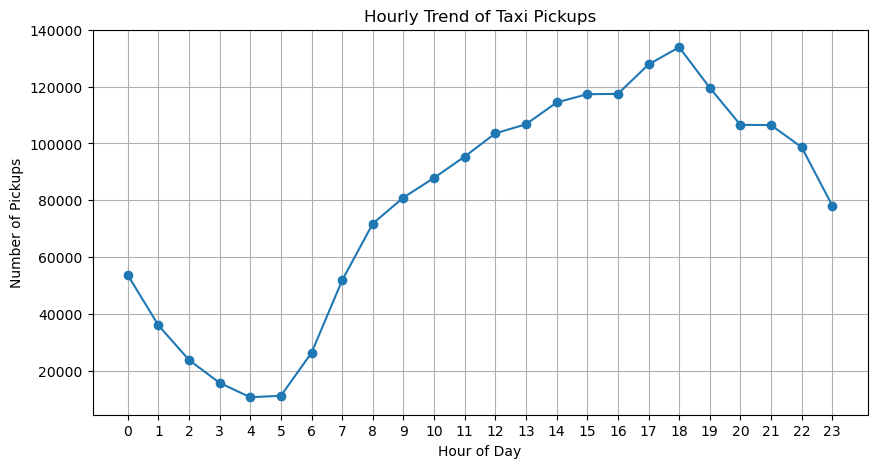

In [509]:
# Find and show the hourly trends in taxi pickups
hourly_pickups = (
    df.groupby("tpep_pickup_hour")
      .size()
      .reset_index(name="pickup_count")
)

plt.figure(figsize=(10, 5))
plt.plot(hourly_pickups["tpep_pickup_hour"], hourly_pickups["pickup_count"], marker="o")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Pickups")
plt.title("Hourly Trend of Taxi Pickups")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()


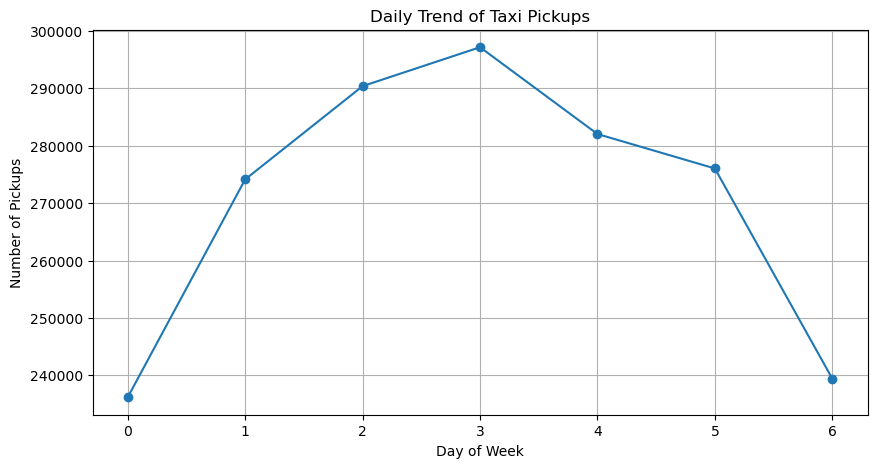

(1895332, 21)


In [510]:
# Find and show the daily trends in taxi pickups (days of the week)
df["weekday"] = df["tpep_pickup_datetime"].dt.weekday   # Monday - 0 

daily_pickups = (
    df.groupby("weekday")
      .size()
      .reset_index(name="count")
)


plt.figure(figsize=(10, 5))
plt.plot(daily_pickups["weekday"],daily_pickups["count"], marker="o")
plt.xlabel("Day of Week")
plt.ylabel("Number of Pickups")
plt.title("Daily Trend of Taxi Pickups")
plt.xticks(range(0, 7))
plt.grid(True)
plt.show()

print(df.shape)

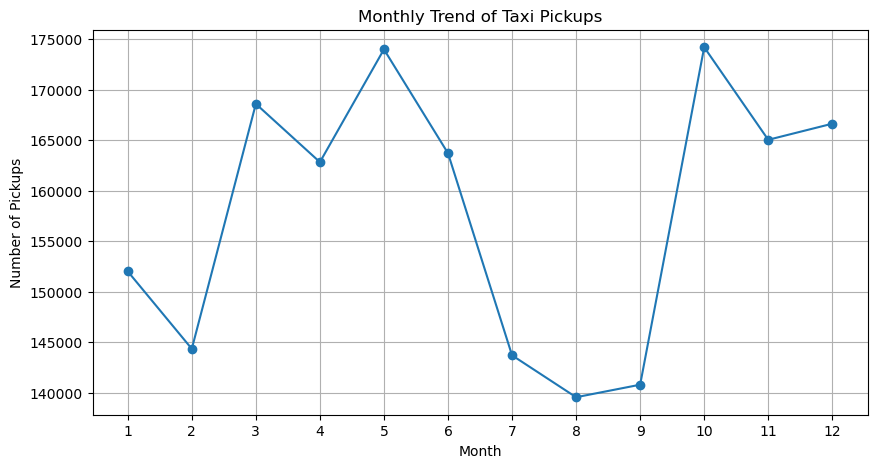

(1895332, 22)


In [511]:
# Show the monthly trends in pickups
df["month"] = df["tpep_pickup_datetime"].dt.month

monthly_pickups = (df.groupby("month").size().reset_index(name="count"))

plt.figure(figsize=(10,5))
plt.plot(monthly_pickups["month"],monthly_pickups["count"],marker="o")
plt.xlabel("Month")
plt.ylabel("Number of Pickups")
plt.title("Monthly Trend of Taxi Pickups")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()
print(df.shape)

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [512]:
# Analyse the above parameters
print(df[df["fare_amount"]<=0].shape[0])
print(df[df["tip_amount"]<=0].shape[0])
print(df[df["total_amount"]<=0].shape[0])
print(df[df["trip_distance"]<=0].shape[0])


561
435231
331
37619


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [522]:
# Create a df with non zero entries for the selected parameters.
df_non_zero = df[
    (df["fare_amount"] > 0) &
    (df["total_amount"] > 0) &
    (df["tip_amount"] >= 0) &
    ((df["trip_distance"] > 0) | ((df["trip_distance"] == 0) & (df["pu_location_id"] == df["do_location_id"])))].copy()
print(df.shape)
print(df_non_zero.shape)


(1895332, 22)
(1873026, 22)


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

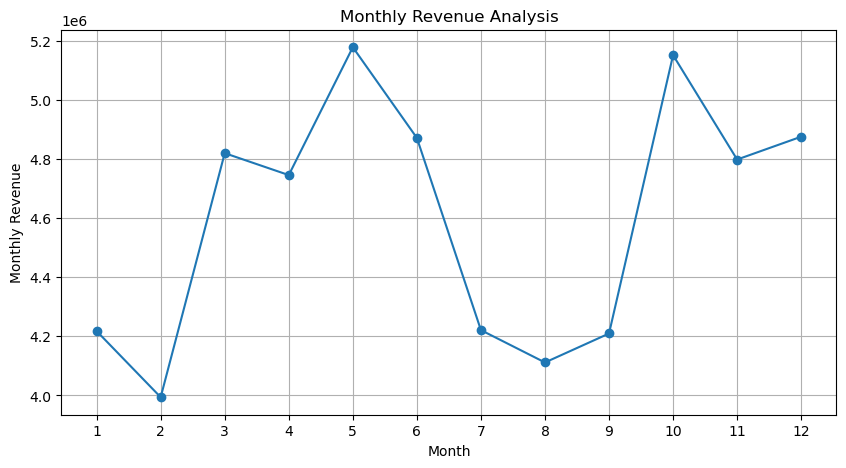

In [524]:
# Group data by month and analyse monthly revenue
monthly_summary = (
    df_non_zero
    .groupby("month")["total_amount"].sum()
    .reset_index(name="monthly_revenue")
)

plt.figure(figsize=(10,5))
plt.plot(monthly_summary["month"],monthly_summary["monthly_revenue"],marker="o")
plt.xlabel("Month")
plt.ylabel("Monthly Revenue")
plt.title("Monthly Revenue Analysis")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()


**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

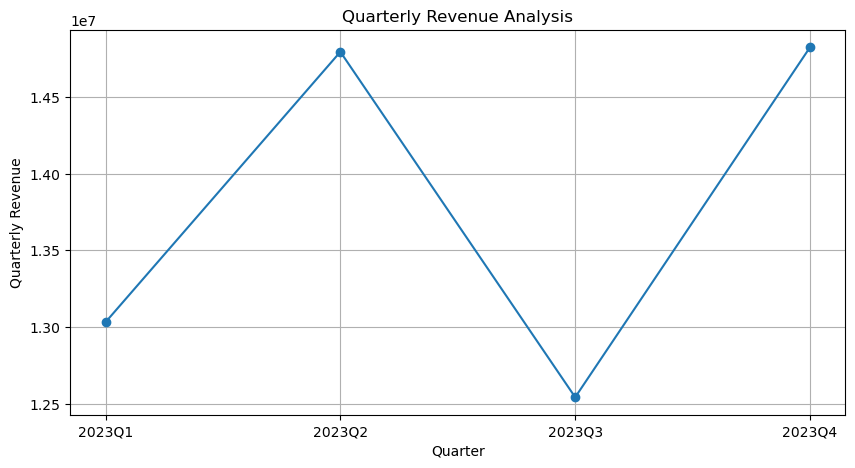

In [525]:
# Calculate proportion of each quarter
df_non_zero["quarter"] = df_non_zero["tpep_pickup_datetime"].dt.to_period("Q")

quarterly_summary = df_non_zero.groupby("quarter")["total_amount"].sum().reset_index(name="quarterly_revenue")

plt.figure(figsize=(10,5))
plt.plot(quarterly_summary["quarter"].astype(str),quarterly_summary["quarterly_revenue"],marker="o")
plt.xlabel("Quarter")
plt.ylabel("Quarterly Revenue")
plt.title("Quarterly Revenue Analysis")
plt.xticks(range(0, 4))
plt.grid(True)
plt.show()

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

(1873026, 23)
               trip_distance  fare_amount
trip_distance       1.000000     0.919432
fare_amount         0.919432     1.000000
(1857414, 23)
               trip_distance  fare_amount
trip_distance        1.00000      0.94443
fare_amount          0.94443      1.00000


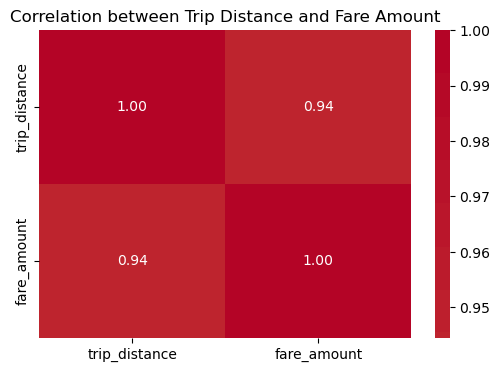

In [526]:
# Show how trip fare is affected by distance
print(df_non_zero.shape)
corr_data = df_non_zero[["trip_distance", "fare_amount"]].corr(method="pearson")
print(corr_data)
#Remove the trips with trip_distance=0
non_zero_trip_duration = df_non_zero[df_non_zero["trip_distance"] > 0]
print(non_zero_trip_duration.shape)
corr_nzdata = non_zero_trip_duration[["trip_distance", "fare_amount"]].corr(method="pearson")
print(corr_nzdata)

plt.figure(figsize=(6, 4))
sns.heatmap(
    corr_nzdata,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation between Trip Distance and Fare Amount")
plt.show()


**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

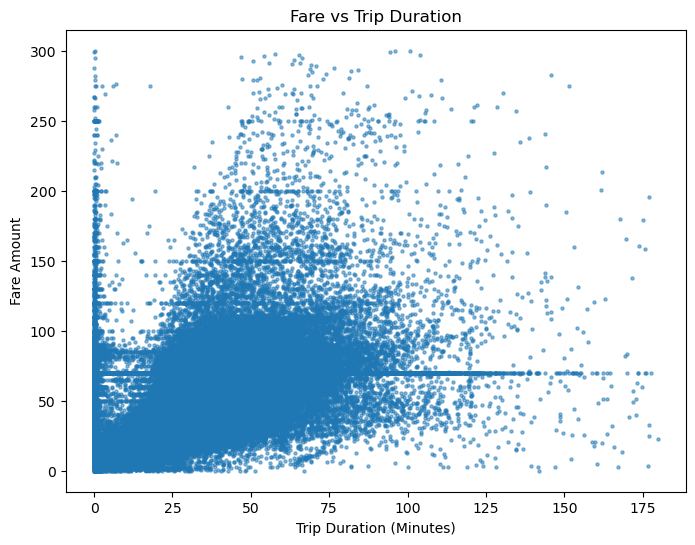

Filtered Data Correlation: 0.824
Non Filtered Data Correlation: 0.277
(1895332, 22)
(1873026, 24)
(1871195, 24)


In [527]:
# Show relationship between fare and trip duration

df_non_zero["trip_duration_min"] = (
    df_non_zero["tpep_dropoff_datetime"] - df_non_zero["tpep_pickup_datetime"]
).dt.total_seconds() / 60

#remove extreme trips for our data analysis and to remove outliers to get clear relationship between data 
df_clean = df_non_zero[
    (df_non_zero["trip_duration_min"] < 180) &   # < 3 hours
    (df_non_zero["fare_amount"] < 300)         
]

plt.figure(figsize=(8,6))

plt.scatter(
    df_clean["trip_duration_min"],
    df_clean["fare_amount"],
    s=5,
    alpha=0.5
)

plt.xlabel("Trip Duration (Minutes)")
plt.ylabel("Fare Amount")
plt.title("Fare vs Trip Duration")

plt.show()

corr_filtered = df_clean["trip_duration_min"].corr(df_clean["fare_amount"])
print("Filtered Data Correlation:", round(corr_filtered, 3))

corr_non_filtered = df_non_zero["trip_duration_min"].corr(df_non_zero["fare_amount"])
print("Non Filtered Data Correlation:", round(corr_non_filtered, 3))

print(df.shape)
print(df_non_zero.shape)
print(df_clean.shape)

0.042


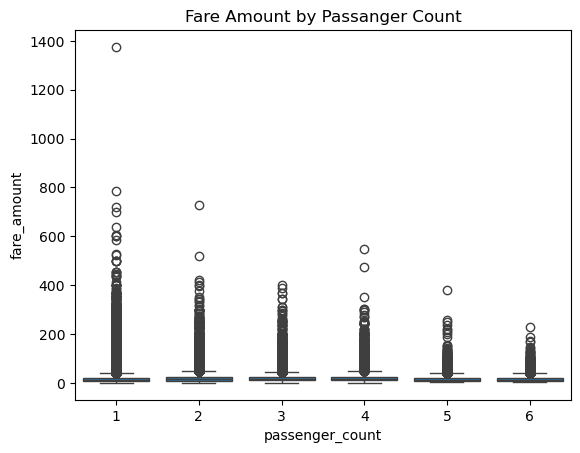

passenger_count
1    1449706
2     276488
3      68818
4      38370
5      23806
6      15838
Name: count, dtype: int64

In [528]:
# Show relationship between fare and number of passengers
corr = df_non_zero["passenger_count"].corr(df_non_zero["fare_amount"])
print(round(corr,3))

sns.boxplot(
    x="passenger_count",
    y="fare_amount",
    data=df_non_zero
)

plt.title("Fare Amount by Passanger Count")
plt.show()
df_non_zero['passenger_count'].value_counts()

0.5751769987183272


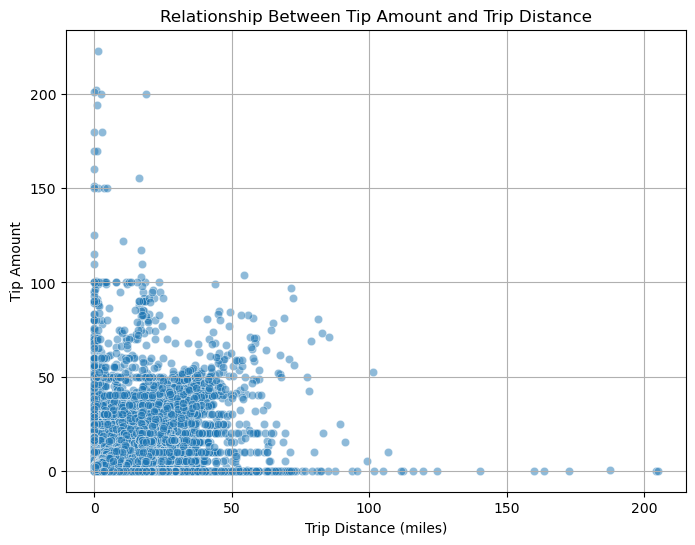

In [530]:
# Show relationship between tip and trip distance
corr = df_non_zero["tip_amount"].corr(df_non_zero["trip_distance"])
print(corr)


plt.figure(figsize=(8, 6))

sns.scatterplot(
    x="trip_distance",
    y="tip_amount",
    data=df_non_zero,
    alpha=0.5
)

plt.title("Relationship Between Tip Amount and Trip Distance")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Tip Amount")
plt.grid(True)

plt.show()

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

(1873026, 24)
(1822433, 24)


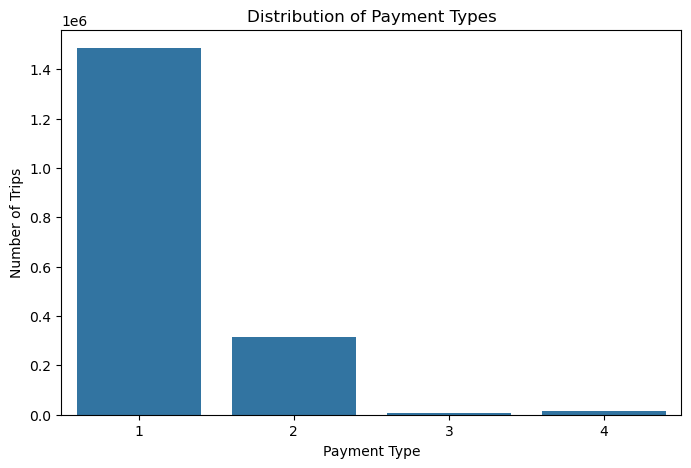

payment_type
1    81.538471
2    17.261430
4     0.731604
3     0.468495
Name: proportion, dtype: float64

In [531]:
# Analyse the distribution of different payment types (payment_type).
#To Standardize remove unknown payment type 99 

df_clean= df_non_zero[df_non_zero["payment_type"]!=99]
print(df_non_zero.shape)
print(df_clean.shape)

plt.figure(figsize=(8, 5))
sns.countplot(
    x="payment_type",
    data=df_clean
)

plt.title("Distribution of Payment Types")
plt.xlabel("Payment Type")
plt.ylabel("Number of Trips")

plt.show()

df_clean["payment_type"].value_counts(normalize=True)*100


- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [42]:
!pip install geopandas


'C:\\Users\\Disha Kakkar\\Graded Assignment Dataset'

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [532]:
# import geopandas as gpd
import geopandas as gpd

# Read the shapefile using geopandas
zones = gpd.read_file("taxi_zones/taxi_zones.shp")   # read the .shp file using gpd
zones.head()
zones.shape

#Drop duplicate records to keep the data clean 
zones  = zones.drop_duplicates(subset="LocationID").reset_index()
print(zones.shape)
print(df_non_zero.shape)

(260, 8)
(1873026, 24)


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   index       260 non-null    int64   
 1   OBJECTID    260 non-null    int32   
 2   Shape_Leng  260 non-null    float64 
 3   Shape_Area  260 non-null    float64 
 4   zone        260 non-null    object  
 5   LocationID  260 non-null    int32   
 6   borough     260 non-null    object  
 7   geometry    260 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), int64(1), object(2)
memory usage: 14.3+ KB
None


<Axes: >

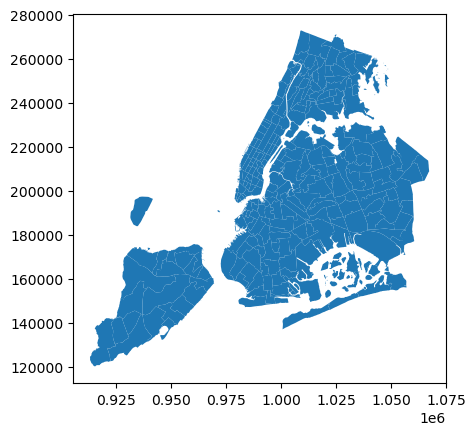

In [533]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [548]:
# Merge zones and trip records using locationID and PULocationID
print(df_non_zero.shape)
df_non_zero.columns
merge_data = pd.merge(df_non_zero,zones,left_on="pu_location_id",right_on="LocationID",how="inner")
merge_data.shape

(1873026, 24)


(1854310, 32)

**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [556]:
# Group data by location and calculate the number of trips
print(df_non_zero.shape)
print(merge_data.shape)
print(df_non_zero[~df_non_zero["pu_location_id"].isin(range(1,264))].shape)
pickup_trips = merge_data.groupby("LocationID").size().reset_index(name="trip_count")
pickup_trips = pickup_trips.sort_values("trip_count", ascending=False)
pickup_trips.head(10)



(1873026, 24)
(1854310, 32)
(18712, 24)


,LocationID,trip_count
124,132,96601
228,237,88156
153,161,86901
227,236,79165
154,162,66333
130,138,64305
177,186,63901
221,230,62105
134,142,62048
162,170,55405


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [557]:
# Merge trip counts back to the zones GeoDataFrame

zones_with_trips = zones.merge(
    pickup_trips,
    on="LocationID",
    how="left"
)


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

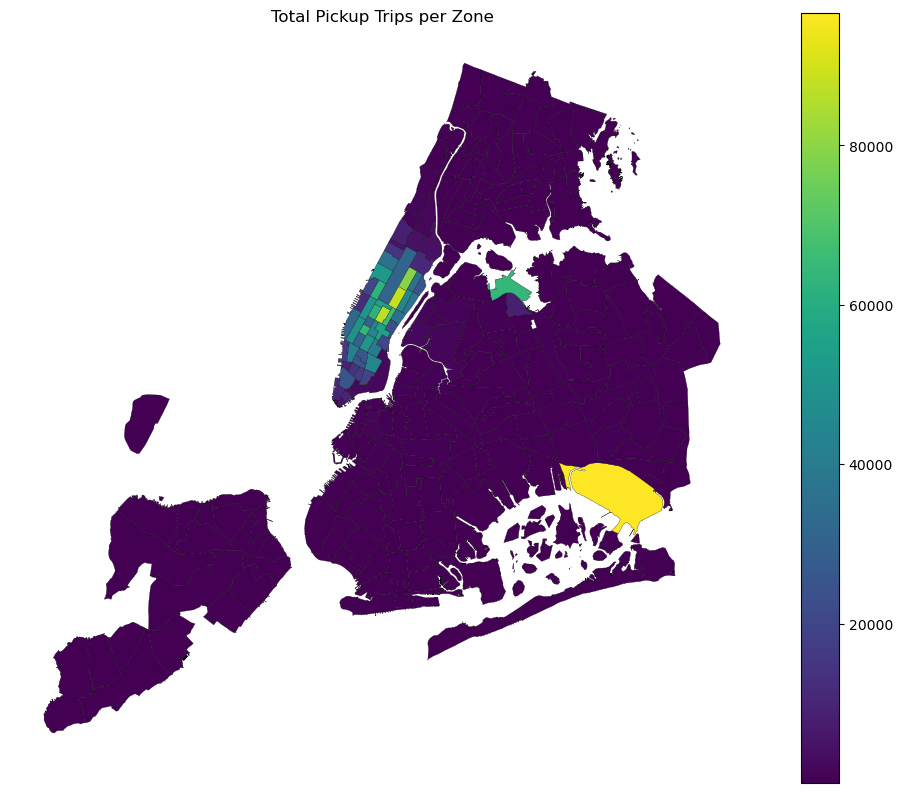

In [558]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot the map and display it

zones_with_trips.plot(
    column="trip_count",
    ax=ax,
    legend=True,
    edgecolor="black",
    linewidth=0.2
)

plt.title("Total Pickup Trips per Zone")
plt.axis("off")
plt.show()


In [561]:
# can you try displaying the zones DF sorted by the number of trips?

zones_sorted = zones_with_trips.sort_values(
    by="trip_count",
    ascending=False
)

zones_sorted.head(10)
merge_data.head(10)

,vendor_id,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,rate_code_id,pu_location_id,do_location_id,payment_type,fare_amount,...,quarter,trip_duration_min,index,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1,7.74,1,138,256,2,32.40,...,2023Q1,15.950000,137,138,0.107467,0.000537,LaGuardia Airport,138,Queens,"MULTIPOLYGON (((1019904.219 225677.983, 102031..."
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2,1.24,1,161,237,1,7.90,...,2023Q1,5.083333,160,161,0.035804,0.000072,Midtown Center,161,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21..."
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3,1.44,1,237,141,2,11.40,...,2023Q1,10.550000,236,237,0.042213,0.000096,Upper East Side South,237,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21..."
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1,0.54,1,143,142,2,6.50,...,2023Q1,5.416667,142,143,0.054180,0.000151,Lincoln Square West,143,Manhattan,"POLYGON ((989338.1 223572.253, 989368.225 2235..."
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,1,19.24,99,66,107,99,25.64,...,2023Q1,18.000000,65,66,0.054633,0.000108,DUMBO/Vinegar Hill,66,Brooklyn,"POLYGON ((990055.507 196472.349, 990004.46 196..."
5,1,2023-01-01 00:42:56,2023-01-01 01:16:33,2,7.10,1,246,37,1,34.50,...,2023Q1,33.616667,245,246,0.069467,0.000281,West Chelsea/Hudson Yards,246,Manhattan,"POLYGON ((983031.177 217138.506, 983640.32 216..."
6,2,2023-01-01 00:58:00,2023-01-01 01:08:31,2,1.59,1,79,164,1,11.40,...,2023Q1,10.516667,78,79,0.042625,0.000108,East Village,79,Manhattan,"POLYGON ((988746.067 202151.955, 988733.885 20..."
7,2,2023-01-01 00:16:06,2023-01-01 00:31:59,1,3.16,1,79,256,1,19.10,...,2023Q1,15.883333,78,79,0.042625,0.000108,East Village,79,Manhattan,"POLYGON ((988746.067 202151.955, 988733.885 20..."
8,2,2023-01-01 00:44:09,2023-01-01 01:01:17,1,7.64,1,132,95,1,31.70,...,2023Q1,17.133333,131,132,0.245479,0.002038,JFK Airport,132,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283..."
9,1,2023-01-01 00:15:25,2023-01-01 00:22:35,2,0.90,1,148,114,1,7.90,...,2023Q1,7.166667,147,148,0.039131,0.000070,Lower East Side,148,Manhattan,"POLYGON ((988552.836 201677.665, 988387.669 20..."


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [577]:
# Find routes which have the slowest speeds at different times of the day
print(df_non_zero.columns)
print(df_non_zero.shape)

zone_map = zones.set_index("LocationID")["zone"]

df_non_zero["pu_zone"] = df_non_zero["pu_location_id"].map(zone_map)
df_non_zero["do_zone"] = df_non_zero["do_location_id"].map(zone_map)

# Remove records with unknown pickup or drop-off zones
df_non_zero = df_non_zero[ df_non_zero["pu_zone"].notnull() & df_non_zero["do_zone"].notnull()].copy()
print(df_non_zero.shape)


#filter out records with 0 trip distance and 0 time taken 
df_non_zero = df_non_zero[
    (df_non_zero["trip_duration_min"] > 0) &
    (df_non_zero["trip_distance"] > 0)
]

print("Removed records with 0 trip distance and 0 time taken",df_non_zero.shape)

df_non_zero["trip_duration_hr"] = df_non_zero["trip_duration_min"] / 60

#CReating Route
df_non_zero["route"] = (
    df_non_zero["pu_zone"].astype(str)
    + " -- " +
    df_non_zero["do_zone"].astype(str)
)

route_hour_stats = (
    df_non_zero
    .groupby(["route", "tpep_pickup_hour"])
    .agg(
        avg_distance=("trip_distance", "mean"),
        avg_duration=("trip_duration_hr", "mean"),
        trip_count=("trip_distance", "count")
    )
    .reset_index()
)

route_hour_stats["speed_mph"] = (
    route_hour_stats["avg_distance"] /
    route_hour_stats["avg_duration"]
)

#To determine slow routes avoid less number of trips records 
route_hour_stats = route_hour_stats[
    route_hour_stats["trip_count"] >= 20
]

slowest_routes_by_hour = (
    route_hour_stats
    .sort_values(["speed_mph"],ascending=True)
    .groupby("tpep_pickup_hour")
    .head(1)
)

# Top 10 slowest route by hours 
slowest_routes_by_hour[
    ["tpep_pickup_hour", "route", "speed_mph", "trip_count"]
].sort_values(["tpep_pickup_hour"],ascending=False)

Index(['vendor_id', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'rate_code_id', 'pu_location_id',
       'do_location_id', 'payment_type', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
       'congestion_surcharge', 'tpep_pickup_date', 'tpep_pickup_hour',
       'airport_fee', 'weekday', 'month', 'quarter', 'trip_duration_min',
       'pu_zone', 'do_zone', 'trip_duration_hr', 'route'],
      dtype='object')
(1829609, 28)
(1829609, 28)
Removed records with 0 trip distance and 0 time taken (1829609, 28)


,tpep_pickup_hour,route,speed_mph,trip_count
108061,23,UN/Turtle Bay South -- Sutton Place/Turtle Bay...,0.720689,25
81194,22,Midtown North -- Times Sq/Theatre District,1.124884,83
82388,21,Midtown South -- Garment District,0.922795,32
78493,20,Midtown East -- Midtown Center,1.020483,87
15693,19,Clinton West -- Times Sq/Theatre District,1.127817,33
70608,18,Lower East Side -- Two Bridges/Seward Park,0.862081,25
42748,17,Greenwich Village South -- Greenwich Village N...,1.222240,44
73641,16,Meatpacking/West Village West -- Greenwich Vil...,0.812520,20
36158,15,Garment District -- Garment District,0.952819,34
13724,14,Clinton East -- Times Sq/Theatre District,0.848256,60


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

(1829609, 28)
Busiest hour is     tpep_pickup_hour  trip_count
18                18      129434


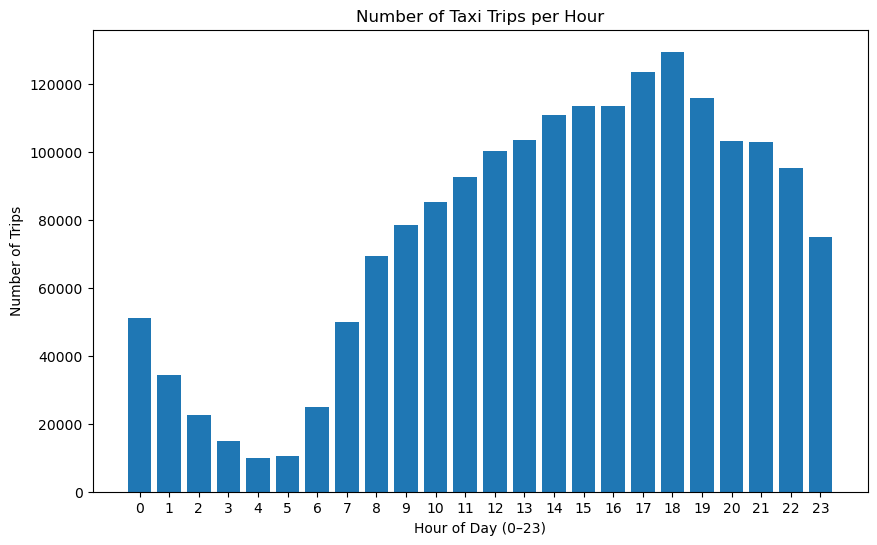

In [578]:
# Visualise the number of trips per hour and find the busiest hour
print(df_non_zero.shape)

hourly_trips = (
    df_non_zero
    .groupby("tpep_pickup_hour")
    .size()
    .reset_index(name="trip_count")
)

hourly_trips_sorted = hourly_trips.sort_values(
    "trip_count",
    ascending=False
)

busiest_hour = hourly_trips_sorted.head(1)
print("Busiest hour is",busiest_hour)

plt.figure(figsize=(10,6))
plt.bar(
    hourly_trips["tpep_pickup_hour"],
    hourly_trips["trip_count"]
)

plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Number of Trips")
plt.title("Number of Taxi Trips per Hour")

plt.xticks(range(24))
plt.show()

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [580]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.05 # as we take hourly 5 % sample
total_trip_per_hour = hourly_trips_sorted["trip_count"]/sample_fraction
total_trip_per_hour.head(5)


18    2588680.0
17    2469820.0
19    2316560.0
15    2271540.0
16    2270620.0
Name: trip_count, dtype: float64

**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

(1829609, 29)


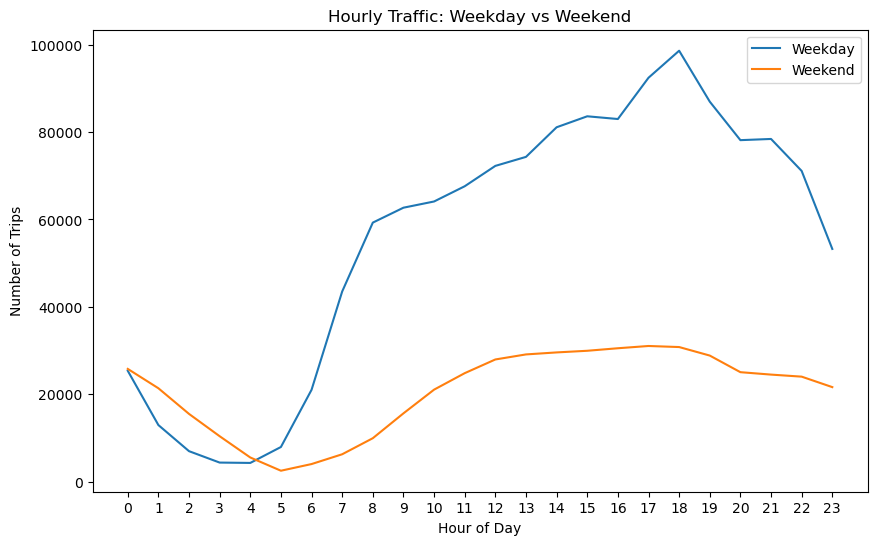

day_type
Weekday    1333503
Weekend     496106
Name: count, dtype: int64

In [583]:
# Compare traffic trends for the week days and weekends
print(df_non_zero.shape)
df_non_zero["day_type"] = df_non_zero["weekday"].apply(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

weekday_hourly = (
    df_non_zero[df_non_zero["day_type"]=="Weekday"]
    .groupby("tpep_pickup_hour")
    .size()
    .reset_index(name="trip_count")
)

weekend_hourly = (
    df_non_zero[df_non_zero["day_type"]=="Weekend"]
    .groupby("tpep_pickup_hour")
    .size()
    .reset_index(name="trip_count")
)

plt.figure(figsize=(10,6))

sns.lineplot(data=weekday_hourly, x="tpep_pickup_hour", y="trip_count", label="Weekday")
sns.lineplot(data=weekend_hourly, x="tpep_pickup_hour", y="trip_count", label="Weekend")
plt.xticks(range(24))
plt.title("Hourly Traffic: Weekday vs Weekend")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")

plt.legend()
plt.show()

df_non_zero["day_type"].value_counts()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

(1829609, 30)


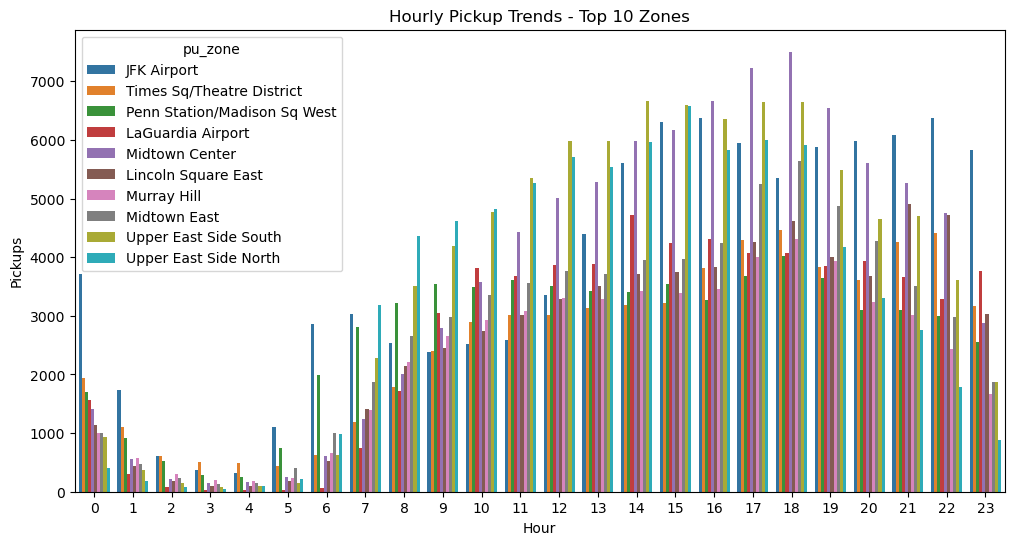

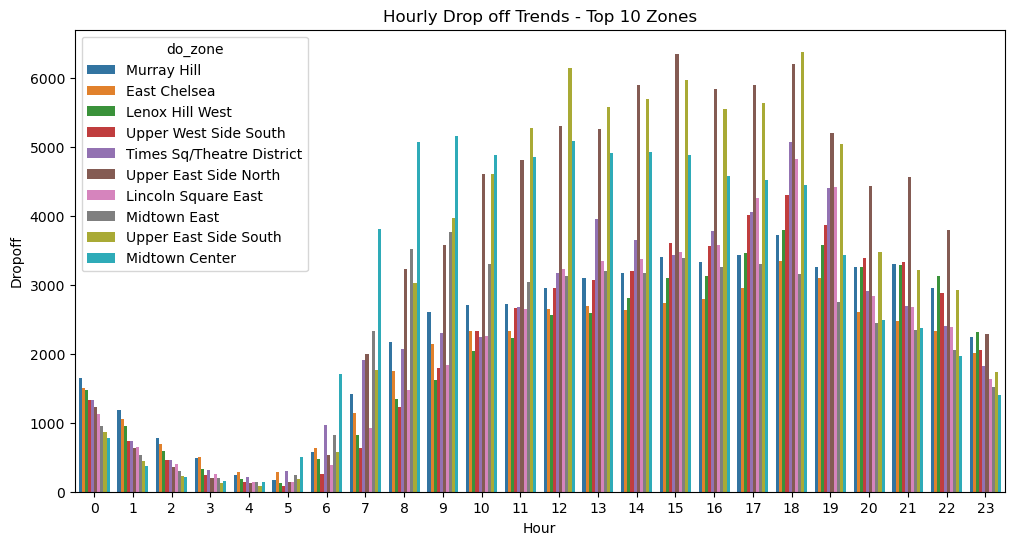

In [585]:
# Find top 10 pickup and dropoff zones
print(df_non_zero.shape)

pickup_hourly  = df_non_zero.groupby(["pu_zone","tpep_pickup_hour"]).size().reset_index(name="pickup_count").sort_values(
    "pickup_count",
    ascending=False
)

#Zones with on an average high hourly pickups
zone_avg_pickup_hourly = (
    pickup_hourly
    .groupby("pu_zone")["pickup_count"]
    .mean()
    .reset_index(name="avg_hourly_pickups")
)

# Top 10 Pickup Zones
top10_pickup_zones = (
    zone_avg_pickup_hourly
    .sort_values("avg_hourly_pickups", ascending=False)
    .head(10)
)


#calculate drop off time 
df_non_zero["tpep_dropoff_hour"] = df_non_zero["tpep_dropoff_datetime"].dt.hour

dropoff_hourly  = df_non_zero.groupby(["do_zone","tpep_dropoff_hour"]).size().reset_index(name="dropoff_count").sort_values(
    "dropoff_count",
    ascending=False
)

#Zones with on an average high hourly dropoffs
zone_avg_dropoff_hourly = (
    dropoff_hourly
    .groupby("do_zone")["dropoff_count"]
    .mean()
    .reset_index(name="avg_hourly_dropoffs")
)

top10_dropoff_zones = (
    zone_avg_dropoff_hourly
    .sort_values("avg_hourly_dropoffs", ascending=False)
    .head(10)
)

# To display trends in top 10 pickup zones

top10zoneList = top10_pickup_zones["pu_zone"]
pickup_trends = pickup_hourly[pickup_hourly["pu_zone"].isin(top10zoneList)]

plt.figure(figsize=(12,6))

sns.barplot(
    data=pickup_trends,
    x="tpep_pickup_hour",
    y="pickup_count",
    hue="pu_zone"
)

plt.title("Hourly Pickup Trends - Top 10 Zones")
plt.xlabel("Hour")
plt.ylabel("Pickups")
plt.show()


# To display trends in top 10 dropoff zones

top10dropoffzoneList = top10_dropoff_zones['do_zone']
dropoff_trends = dropoff_hourly[dropoff_hourly['do_zone'].isin(top10dropoffzoneList)]

plt.figure(figsize=(12,6))

sns.barplot(
    data=dropoff_trends,
    x="tpep_dropoff_hour",
    y="dropoff_count",
    hue="do_zone"
)

plt.title("Hourly Drop off Trends - Top 10 Zones")
plt.xlabel("Hour")
plt.ylabel("Dropoff")
plt.show()

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [591]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
pickup_counts = df_non_zero.groupby("pu_zone").size().reset_index(name="pickups")
dropoff_counts = df_non_zero.groupby("do_zone").size().reset_index(name="dropoffs")

zone_counts = pd.merge( pickup_counts, dropoff_counts, left_on="pu_zone", right_on="do_zone", how="outer" )

#It might be possible that some zones appear only in pickups and some zones appear only in dropoffs and some appear in both
# Thats why we are using Combine first approach , it means it will fetch value from first not nan zone. 
zone_counts["zone"] = zone_counts["pu_zone"].combine_first(zone_counts["do_zone"])

zone_counts = zone_counts[["zone", "pickups", "dropoffs"]].fillna(0)
# To avoid divison by 0 -> Infinity we replace 0 with NA
zone_counts["dropoffs"] = zone_counts["dropoffs"].replace(0, pd.NA) 

zone_counts["pickup_drop_ratio"] = zone_counts["pickups"] / zone_counts["dropoffs"]

top10_ratio = zone_counts.sort_values("pickup_drop_ratio", ascending=False).head(10) 
bottom10_ratio = zone_counts.sort_values("pickup_drop_ratio", ascending=True).head(10)
print("Top 10 zones by pickup/dropoff ratio:")
print(top10_ratio) 
print("Bottom 10 zones by pickup/dropoff ratio:")
print(bottom10_ratio)

Top 10 zones by pickup/dropoff ratio:
                             zone  pickups dropoffs pickup_drop_ratio
66                  East Elmhurst   8078.0    872.0          9.263761
121                   JFK Airport  91257.0  20904.0          4.365528
131             LaGuardia Airport  62773.0  23967.0          2.619143
180  Penn Station/Madison Sq West  63357.0  40506.0          1.564139
106       Greenwich Village South  24622.0  17905.0          1.375147
40                   Central Park  30960.0  22618.0          1.368821
243                  West Village  41104.0  30935.0          1.328722
155                  Midtown East  65856.0  52897.0          1.244986
154                Midtown Center  86318.0  72696.0          1.187383
96               Garment District  30214.0  25477.0          1.185932
Bottom 10 zones by pickup/dropoff ratio:
                                    zone  pickups dropoffs pickup_drop_ratio
215                            Stapleton      0.0     34.0               0

**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [592]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

night_pickups_df = df_non_zero[
    (df_non_zero["tpep_pickup_hour"] >= 23) | (df_non_zero["tpep_pickup_hour"] <= 5)
]

night_dropoffs_df = df_non_zero[
    (df_non_zero["tpep_dropoff_hour"] >= 23) | (df_non_zero["tpep_dropoff_hour"] <= 5)
]

top10nightpickups = (
    night_pickups_df.groupby("pu_zone").size().reset_index(name="night_pickups").sort_values("night_pickups", ascending=False).head(10)
)

top10nightdropoffs = (
     night_dropoffs_df.groupby("do_zone").size().reset_index(name="night_dropoff").sort_values("night_dropoff",ascending=False).head(10)
                )

print(top10nightpickups)
print(top10nightdropoffs)
              


                          pu_zone  night_pickups
69                   East Village          15958
109                   JFK Airport          13683
220                  West Village          12751
41                   Clinton East          10540
128               Lower East Side           9912
96        Greenwich Village South           8939
202     Times Sq/Theatre District           8252
163  Penn Station/Madison Sq West           6959
143                 Midtown South           6255
58                   East Chelsea           6129
                       do_zone  night_dropoff
75                East Village           9025
45                Clinton East           7591
162                Murray Hill           6766
64                East Chelsea           6337
100                   Gramercy           6204
133            Lenox Hill West           5955
254             Yorkville West           5659
240               West Village           5367
221  Times Sq/Theatre District           5183
2

Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [601]:
# Filter for night hours (11 PM to 5 AM)
df_non_zero["time_period"] = df_non_zero["tpep_pickup_hour"].apply(
    lambda x: "Night" if x >= 23 or x <=5 else "Day"
)

revenue_split = (
    df_non_zero
    .groupby("time_period")["total_amount"]
    .sum()
    .reset_index(name="total_revenue")
)

total = revenue_split["total_revenue"].sum()

revenue_split["revenue_percent"] = (
    revenue_split["total_revenue"] / total * 100
)

df_non_zero.groupby("time_period")["fare_amount"].mean()
    

time_period
Day      19.328114
Night    19.783364
Name: fare_amount, dtype: float64

##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [605]:
# Analyse the fare per mile per passenger for different passenger counts

#To determine average fare per mile we need to remove trips where trip distance is 0 or fare amount or passenger is 0.
valid_df = df_non_zero[
    (df_non_zero["trip_distance"] > 0) &
    (df_non_zero["fare_amount"] > 0) &
    (df_non_zero["passenger_count"] > 0)
].copy()

valid_df["fare_per_mile"] = (valid_df["fare_amount"]/valid_df["trip_distance"])

#for very short trips with high fare may impact our analysis hence taking upper cap of 0.99 percentile to remove extreme cases

print(valid_df["fare_per_mile"].quantile(0.99))
print(valid_df.shape)
valid_df = valid_df[valid_df["fare_per_mile"]<=valid_df["fare_per_mile"].quantile(0.99)]
print(valid_df.shape)

avg_fare_per_mile  = (valid_df.groupby("passenger_count")["fare_per_mile"]).mean().reset_index(name='avg_fare_per_mile_pg')

avg_fare_per_mile["fare_per_mile_per_passenger"] = ( avg_fare_per_mile["avg_fare_per_mile_pg"] / avg_fare_per_mile["passenger_count"] )

print(avg_fare_per_mile)


22.54098360655738
(1829609, 32)
(1811313, 32)
   passenger_count  avg_fare_per_mile_pg  fare_per_mile_per_passenger
0                1              7.660854                     7.660854
1                2              7.488905                     3.744453
2                3              7.607484                     2.535828
3                4              7.555669                     1.888917
4                5              7.537638                     1.507528
5                6              7.619932                     1.269989


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

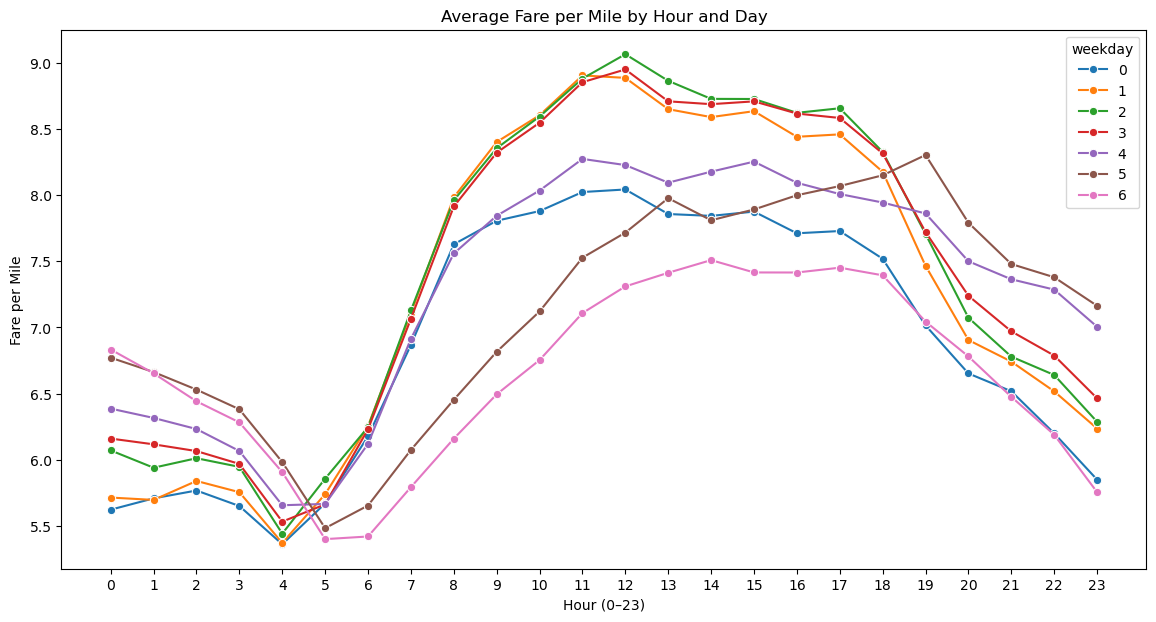

In [606]:
# Compare the average fare per mile for different days and for different times of the day
average_fare_per_miles_day_time = valid_df.groupby(["weekday","tpep_pickup_hour"])["fare_per_mile"].mean().reset_index(name="fare_per_mile")
average_fare_per_miles_day_time

plt.figure(figsize=(14,7))

sns.lineplot(
    data=average_fare_per_miles_day_time,
    x="tpep_pickup_hour",
    y="fare_per_mile",
    hue="weekday",
    palette="tab10",
    marker="o"
)

plt.xticks(range(24))
plt.title("Average Fare per Mile by Hour and Day")
plt.xlabel("Hour (0–23)")
plt.ylabel("Fare per Mile")

plt.show()

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

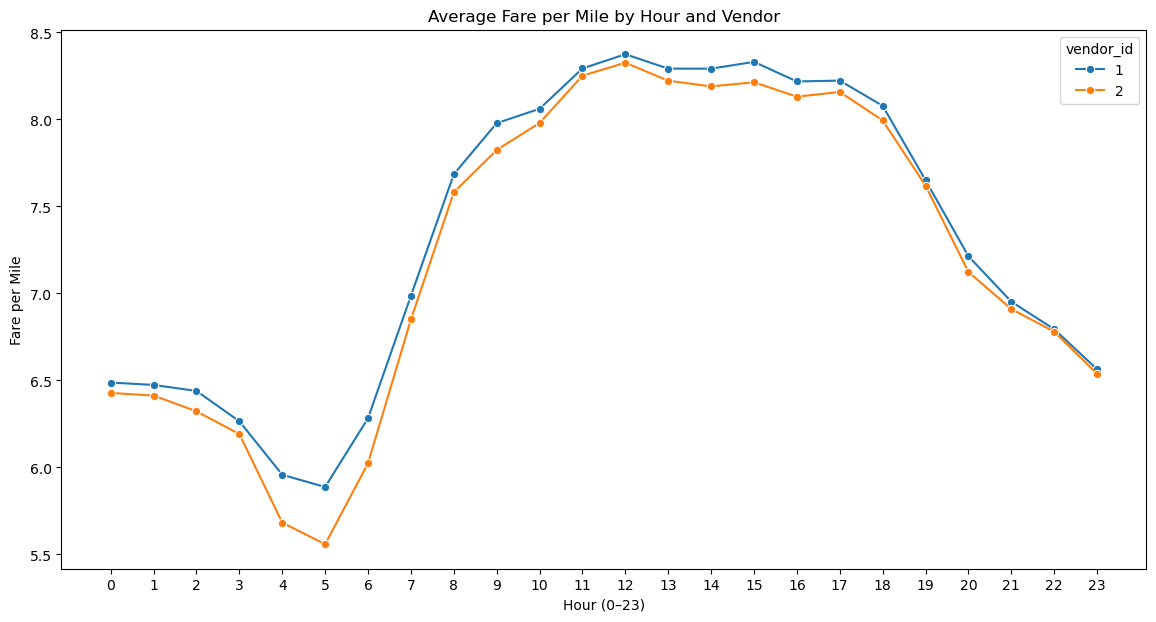

In [629]:
# Compare fare per mile for different vendors
average_fare_per_miles_vendors_time = valid_df.groupby(["vendor_id","tpep_pickup_hour"])["fare_per_mile"].mean().reset_index(name='fare_per_mile')
average_fare_per_miles_vendors_time

plt.figure(figsize=(14,7))

sns.lineplot(
    data=average_fare_per_miles_vendors_time,
    x="tpep_pickup_hour",
    y="fare_per_mile",
    hue="vendor_id",
    palette="tab10",
    marker="o"
)

plt.xticks(range(24))
plt.title("Average Fare per Mile by Hour and Vendor")
plt.xlabel("Hour (0–23)")
plt.ylabel("Fare per Mile")

plt.show()

# REcords with vendor id are mostly inaccurate with invalid pickup or drop off zones. 

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


C:\Users\Disha Kakkar\AppData\Local\Temp\ipykernel_24848\1066641025.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["vendor_id", "distance_tier"])["fare_per_mile"]


<Axes: xlabel='distance_tier', ylabel='fare_per_mile'>

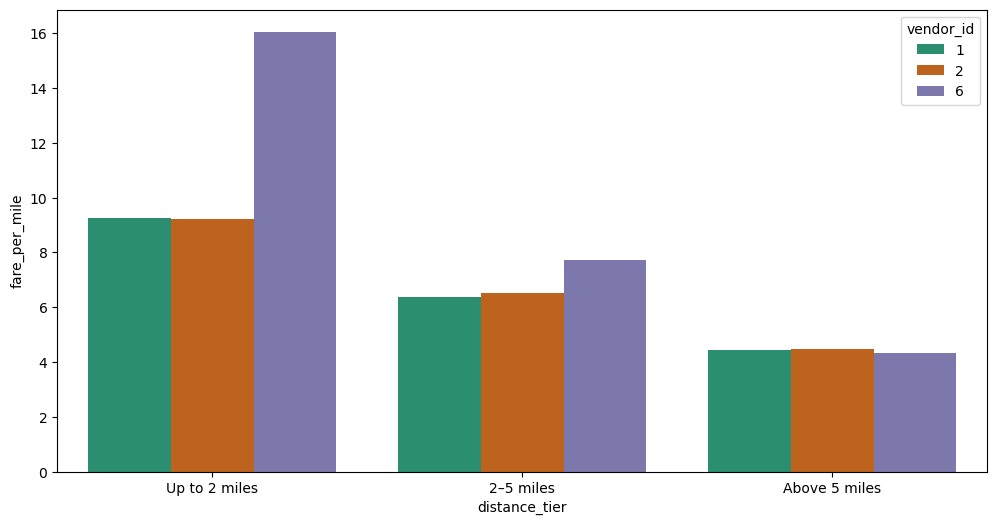

In [326]:
# Defining distance tiers
valid_df.shape

bins = [0, 2, 5, float("inf")]
labels = ["Up to 2 miles", "2–5 miles", "Above 5 miles"]

valid_df["distance_tier"] = pd.cut(
    valid_df["trip_distance"],
    bins=bins,
    labels=labels
)

tier_summary = (
    valid_df
    .groupby(["vendor_id", "distance_tier"])["fare_per_mile"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=tier_summary,
    x="distance_tier",
    y="fare_per_mile",
    hue="vendor_id",
    palette="Dark2"
)

##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

C:\Users\Disha Kakkar\AppData\Local\Temp\ipykernel_24848\1357630129.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("distance_tier")["tip_pct"]


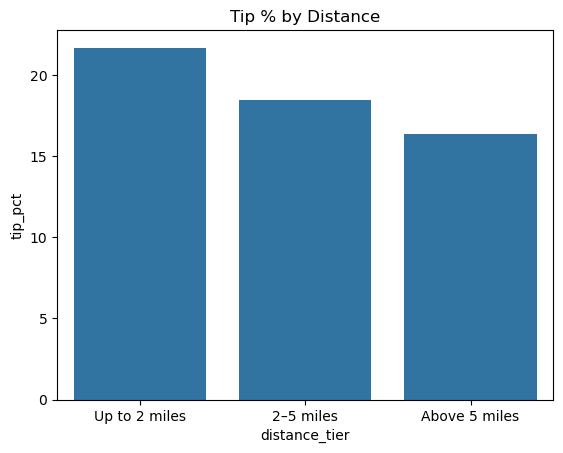

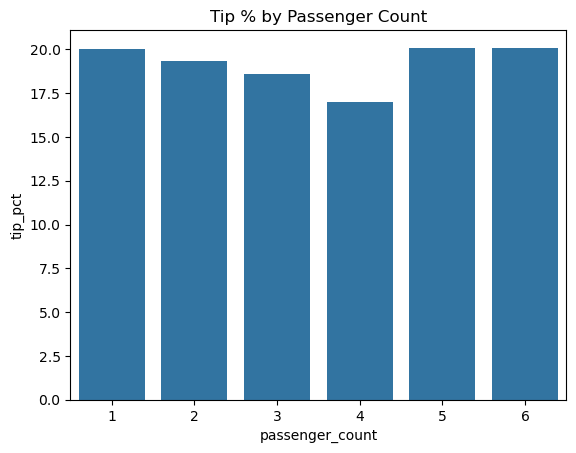

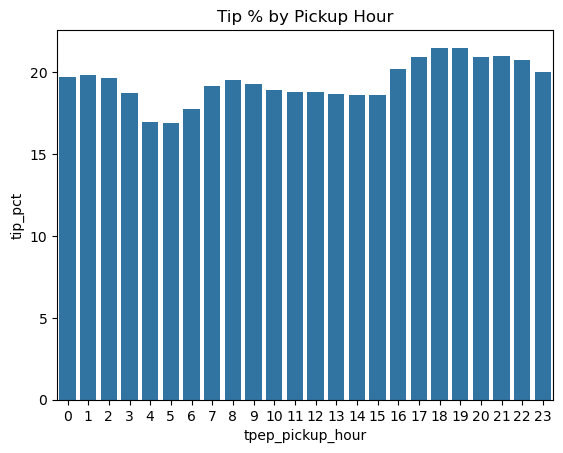

In [342]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
valid_df["tip_pct"] = valid_df["tip_amount"] / valid_df["fare_amount"] * 100
df_clean = valid_df.copy()

#Remove extreme tip cases for our analysis
upper = df_clean["tip_pct"].quantile(0.99)
df_clean = df_clean[df_clean["tip_pct"] <= upper]

#EArlier we create bins of trip distance, hence analyzing it based on those bins in trip distance
tip_by_distance = (
    df_clean
    .groupby("distance_tier")["tip_pct"]
    .mean()
    .reset_index()
)

tip_by_passenger = (
    df_clean
    .groupby("passenger_count")["tip_pct"]
    .mean()
    .reset_index()
)

tip_by_hour = (
    df_clean
    .groupby("tpep_pickup_hour")["tip_pct"]
    .mean()
    .reset_index()
)

sns.barplot(data=tip_by_distance, x="distance_tier", y="tip_pct")
plt.title("Tip % by Distance")
plt.show()

sns.barplot(data=tip_by_passenger, x="passenger_count", y="tip_pct")
plt.title("Tip % by Passenger Count")
plt.show()

sns.barplot(data=tip_by_hour,x="tpep_pickup_hour",y="tip_pct")
plt.title("Tip % by Pickup Hour")
plt.show()

Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [399]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%

#Our df_clean dataset does not include extreme tip cases hence continue our analysis with that.

df_clean[df_clean["tip_pct"]>25]


,vendor_id,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,rate_code_id,pu_location_id,do_location_id,payment_type,fare_amount,...,pu_zone,do_zone,trip_duration_hr,route,day_type,tpep_dropoff_hour,time_period,fare_per_mile,tip_pct,distance_tier
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2,1.24,1,161,237,1,7.90,...,Midtown Center,Upper East Side South,0.084722,Midtown Center -- Upper East Side South,Weekend,0,Night,6.370968,32.658228,Up to 2 miles
6,2,2023-01-01 00:58:00,2023-01-01 01:08:31,2,1.59,1,79,164,1,11.40,...,East Village,Midtown South,0.175278,East Village -- Midtown South,Weekend,1,Night,7.169811,28.771930,Up to 2 miles
7,2,2023-01-01 00:16:06,2023-01-01 00:31:59,1,3.16,1,79,256,1,19.10,...,East Village,Williamsburg (South Side),0.264722,East Village -- Williamsburg (South Side),Weekend,0,Night,6.044304,31.518325,2–5 miles
11,2,2023-01-01 00:24:48,2023-01-01 00:45:04,1,2.78,1,79,186,1,19.80,...,East Village,Penn Station/Madison Sq West,0.337778,East Village -- Penn Station/Madison Sq West,Weekend,0,Night,7.122302,25.050505,2–5 miles
12,2,2023-01-01 00:27:33,2023-01-01 00:36:38,2,0.85,1,90,68,1,10.00,...,Flatiron,East Chelsea,0.151389,Flatiron -- East Chelsea,Weekend,0,Night,11.764706,37.500000,Up to 2 miles
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1896386,2,2023-09-30 22:40:07,2023-09-30 22:58:17,1,2.93,1,186,231,1,19.10,...,Penn Station/Madison Sq West,TriBeCa/Civic Center,0.302778,Penn Station/Madison Sq West -- TriBeCa/Civic ...,Weekend,22,Day,6.518771,25.235602,2–5 miles
1896395,2,2023-09-30 22:28:34,2023-09-30 22:33:41,2,0.86,1,261,88,1,7.20,...,World Trade Center,Financial District South,0.085278,World Trade Center -- Financial District South,Weekend,22,Day,8.372093,42.361111,Up to 2 miles
1896397,2,2023-09-30 22:35:50,2023-09-30 22:43:17,1,1.38,99,50,68,99,14.48,...,Clinton West,East Chelsea,0.124167,Clinton West -- East Chelsea,Weekend,22,Day,10.492754,25.552486,Up to 2 miles
1896398,2,2023-09-30 22:59:21,2023-09-30 23:10:16,1,1.03,1,142,230,1,10.70,...,Lincoln Square East,Times Sq/Theatre District,0.181944,Lincoln Square East -- Times Sq/Theatre District,Weekend,23,Day,10.388350,29.345794,Up to 2 miles


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

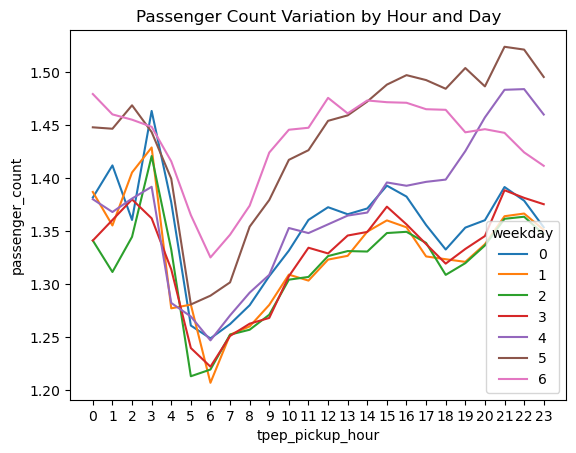

In [370]:
# See how passenger count varies across hours and days

#Our analysis of passanger count across hours and days of the week nothing to do with fare per miles. Hence instead of using valid_df where we are 
#using 99 percentile of fare per miles data. We use our initial df_non_zero dataset to get better insight

passenger_summary =  df_non_zero.groupby(["weekday","tpep_pickup_hour"])["passenger_count"].mean().reset_index(name="passenger_count")

sns.lineplot(
    data=passenger_summary,
    x="tpep_pickup_hour",
    y="passenger_count",
    hue="weekday",
    palette="tab10"
)

plt.xticks(range(24))
plt.title("Passenger Count Variation by Hour and Day")
plt.show()

#1.20 on an average can be considered as more solo trips 
#1.45 and above an average can be considered as more group trips 


**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [375]:
# How does passenger count vary across zones

#Basic Average passenger count per zone
passanger_count_zones = df_non_zero.groupby("pu_zone")["passenger_count"].mean().reset_index().sort_values("passenger_count", ascending=False)
#Where trips have more people on an average
passanger_count_zones.head(10)

#Passanger distribution per zone
zone_pass_dist = (
    df_non_zero
    .groupby(["pu_zone","passenger_count"])
    .size()
    .reset_index(name="count")
)

zone_pass_dist["pct"] = (
    zone_pass_dist
    .groupby("pu_zone")["count"]
    .transform(lambda x: x / x.sum() * 100)
)

zone_pass_dist

,pu_zone,passenger_count,count,pct
0,Allerton/Pelham Gardens,1,32,100.000000
1,Alphabet City,1,1731,78.574671
2,Alphabet City,2,296,13.436223
3,Alphabet City,3,94,4.266909
4,Alphabet City,4,38,1.724921
...,...,...,...,...
959,Yorkville West,2,4716,13.179443
960,Yorkville West,3,1044,2.917587
961,Yorkville West,4,416,1.162563
962,Yorkville West,5,554,1.548221


In [390]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.

avg_passenger_zone = (
    df_non_zero
    .groupby("pu_location_id")["passenger_count"]
    .mean()
    .reset_index(name="avg_passenger_count")
)


zones_with_trips = zones_with_trips.merge(
    avg_passenger_zone,
    left_on="LocationID",
    right_on="pu_location_id",
    how="left"
)

zones_with_trips[["zone","avg_passenger_count"]].head()

,zone,avg_passenger_count
0,Newark Airport,1.292683
1,Jamaica Bay,1.000000
2,Allerton/Pelham Gardens,1.000000
3,Alphabet City,1.359056
4,Arden Heights,1.000000


Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [ ]:
# How often is each surcharge applied?



## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.